# BUSI 乳腺超声图像分类（良性 vs 恶性）

**任务**：训练一个深度学习模型，根据乳腺超声图像（BUS image）预测肿瘤是 **良性（benign）** 还是 **恶性（malignant）**。

**模型**：ResNet50，加载在 ImageNet 上预训练的权重，替换最后的全连接层做二分类。

**数据**：BUSI 数据集，输入图像统一 resize 到 224×224；数据集自带两个 `.xlsx` 文件，分别给出训练集和测试集的划分。

**这个 notebook 的结构**：
1. 配置（路径、超参数）
2. 导入库
3. 读取并检查数据划分文件（.xlsx）
4. 构建 Dataset / DataLoader（含预处理和数据增强）
5. 可视化几个样本，确认数据加载正确
6. 构建 ResNet50 模型
7. 定义损失函数与优化器
8. 训练循环（记录每个 epoch 的 train loss / test loss）
9. 绘制 loss 曲线
10. 在测试集上计算 accuracy / recall / F1 等指标
11. 可视化测试集预测结果（图片 + 真实标签 + 预测标签）
12. 保存模型

> ⚠️ **在运行之前**：请先把 BUSI 数据集上传到服务器的 `~/datasets/BUSI/` 目录下（图片文件夹 + 两个 .xlsx 划分文件），然后检查第 3 节的输出，确认 CONFIG 里的列名/路径设置和实际文件一致，必要时按提示修改。


## 1. 配置（CONFIG）

把所有“会因为环境/数据不同而需要修改”的东西集中放在这里，后面的代码都引用这些变量，方便统一调整。

🔧 **需要你核对/修改的地方**：
- `DATASET_DIR`：数据集所在目录
- `TRAIN_XLSX` / `TEST_XLSX`：训练集/测试集划分文件的文件名（改成你上传的实际文件名）
- `IMAGES_ROOT`：图片所在的根目录（如果 xlsx 里的路径不是相对这个目录，请调整）
- 第 3 节运行后会打印出 xlsx 的列名，如果和代码里自动识别的不一致，请回到这里手动设置 `IMAGE_COL` / `LABEL_COL`


In [1]:
import os

# ===== 路径配置 =====
DATASET_DIR = os.path.expanduser("~/datasets/BUSI")   # 数据集根目录
TRAIN_XLSX = os.path.join(DATASET_DIR, "train.xlsx")   # 训练集划分文件（文件名不对就改这里）
TEST_XLSX = os.path.join(DATASET_DIR, "test.xlsx")     # 测试集划分文件（文件名不对就改这里）
IMAGES_ROOT = os.path.join(DATASET_DIR, "images")      # 图片实际存放的文件夹（BUSI 传上来后图片在 images/ 子目录下）

# 如果自动识别列名失败，就把下面两个改成 None 以外的具体列名，例如 "image_name" / "label"
IMAGE_COL = None   # 图片文件名/路径所在的列，留 None 则自动尝试识别
LABEL_COL = None   # 类别标签所在的列，留 None 则自动尝试识别

# 类别标签映射：这里只是初始占位值，实际会在第 3 节根据数据自动核实/覆盖
# （不同数据集给数字标签的约定可能不一样，比如 0 到底是 benign 还是 malignant，不能凭经验瞎猜）
LABEL_MAP = {"benign": 0, "malignant": 1}
CLASS_NAMES = ["benign", "malignant"]  # 占位，第 3 节会根据实际数据重新赋值

# ===== 训练超参数 =====
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_WORKERS = 0  # 数据集不大，单进程读取就够快了；如果 /dev/shm 空间充足，可以调大加速数据加载
RANDOM_SEED = 42

# ===== 抗过拟合相关超参数（对照 Job 44：train loss 降到 0.007 但 test loss 在 0.3~0.5 震荡，
# 明显过拟合，这一版加了更强的数据增强 + weight decay + dropout + early stopping） =====
WEIGHT_DECAY = 1e-2       # AdamW 的权重衰减，相当于对参数加 L2 正则
DROPOUT_P = 0.3           # 分类头前的 dropout 概率
EARLY_STOPPING_PATIENCE = 8  # test F1 连续这么多个 epoch 没提升就提前停止
                              # （测试集只有 130 张图，逐 epoch F1 波动较大，patience=5 曾经
                              # 在第 4 轮达到峰值后就被噪声提前叫停，8 给模型多一点机会）

# ===== 输出路径 =====
OUTPUT_DIR = os.path.expanduser("~/projects/research_training/outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, "resnet50_busi_final.pt")
LOSS_CURVE_PATH = os.path.join(OUTPUT_DIR, "loss_curve.png")

print("数据集目录:", DATASET_DIR)
print("模型/图表会保存到:", OUTPUT_DIR)


数据集目录: /mnt/cv_data/users/hahaxixi/datasets/BUSI
模型/图表会保存到: /mnt/cv_data/users/hahaxixi/projects/research_training/outputs


## 2. 导入需要的库

In [2]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix

# 固定随机种子，让结果尽量可复现
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用的 device:", device)


使用的 device: cuda


## 3. 读取并检查数据划分文件（.xlsx）

先只是把两个 xlsx 读进来看一眼——确认文件存在、看看有哪些列、标签长什么样。
**这一步很重要**：如果自动识别的列名不对，第 4 节的 Dataset 会报错或者结果不对，所以先在这里确认清楚。


In [3]:
if not os.path.exists(TRAIN_XLSX) or not os.path.exists(TEST_XLSX):
    raise FileNotFoundError(
        f"没有找到划分文件，请确认已经把 BUSI 数据集上传到 {DATASET_DIR}，\n"
        f"并且训练/测试划分文件名分别是 '{os.path.basename(TRAIN_XLSX)}' 和 '{os.path.basename(TEST_XLSX)}'。\n"
        f"如果实际文件名不同，请回到第 1 节的 CONFIG 里修改 TRAIN_XLSX / TEST_XLSX。"
    )

train_df = pd.read_excel(TRAIN_XLSX)
test_df = pd.read_excel(TEST_XLSX)

print("训练集 xlsx 的列:", list(train_df.columns))
print("训练集样本数:", len(train_df))
print(train_df.head())
print()
print("测试集 xlsx 的列:", list(test_df.columns))
print("测试集样本数:", len(test_df))
print(test_df.head())


训练集 xlsx 的列: ['Image', 'Label']
训练集样本数: 517
              Image  Label
0  benign (218).png      1
1   benign (58).png      1
2  benign (179).png      1
3  benign (410).png      1
4   benign (16).png      1

测试集 xlsx 的列: ['Image', 'Label']
测试集样本数: 130
                Image  Label
0  malignant (30).png      0
1    benign (110).png      1
2    benign (245).png      1
3     benign (22).png      1
4    benign (399).png      1


In [4]:
def guess_column(df, candidates):
    """在 df 的列名里，按候选名单（不区分大小写）找第一个匹配的列。"""
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None


# 自动识别“图片文件名/路径”所在的列，以及“标签”所在的列
if IMAGE_COL is None:
    IMAGE_COL = guess_column(
        train_df, ["image_path", "image_name", "image_id", "filename", "file_name", "image", "path"]
    )
if LABEL_COL is None:
    LABEL_COL = guess_column(train_df, ["label", "class", "category", "diagnosis", "target"])

if IMAGE_COL is None or LABEL_COL is None:
    raise ValueError(
        f"没能自动识别出图片列/标签列，当前列名是: {list(train_df.columns)}\n"
        f"识别结果 IMAGE_COL={IMAGE_COL}, LABEL_COL={LABEL_COL}\n"
        f"请回到第 1 节的 CONFIG，把 IMAGE_COL / LABEL_COL 手动改成正确的列名。"
    )

print(f"图片列: '{IMAGE_COL}'，标签列: '{LABEL_COL}'")
print("训练集标签分布:")
print(train_df[LABEL_COL].value_counts())
print("测试集标签分布:")
print(test_df[LABEL_COL].value_counts())


图片列: 'Image'，标签列: 'Label'
训练集标签分布:
Label
1    346
0    171
Name: count, dtype: int64
测试集标签分布:
Label
1    91
0    39
Name: count, dtype: int64


### 3.1 核实数字标签到底代表哪个类别

`Label` 列里的值已经是数字（比如 0/1），但**不能凭经验假设 0 就是 benign、1 就是 malignant**——
不同数据集的约定可能不一样。BUSI 的图片文件名本身就写了类别（比如 `benign (218).png`），
所以这里用文件名反过来核实一下：每个数字到底对应哪个类别名字，两个数字必须是"一对一"、没有矛盾，
才能放心继续往下用。


In [5]:
combined_df = pd.concat([train_df, test_df], ignore_index=True)

# 从文件名开头提取类别名字，例如 "benign (218).png" -> "benign"
name_from_file = combined_df[IMAGE_COL].astype(str).str.extract(r"^([A-Za-z]+)")[0].str.lower()
label_value = combined_df[LABEL_COL]

check_table = pd.crosstab(label_value, name_from_file)
print("数字标签 vs 文件名类别 交叉表（每个数字应该只对应一个类别名）:")
print(check_table)

# 每个数字标签值应该唯一对应一个类别名字，否则说明假设有问题，不能继续
id_to_name = {}
for label_id, row in check_table.iterrows():
    matched_names = row[row > 0].index.tolist()
    assert len(matched_names) == 1, (
        f"数字标签 {label_id} 同时对应了多个类别名 {matched_names}，"
        f"说明 IMAGE_COL/LABEL_COL 或者数据本身有问题，需要人工检查。"
    )
    id_to_name[int(label_id)] = matched_names[0]

# 根据核实结果，重新生成 CLASS_NAMES（按数字大小排序）和 LABEL_MAP，覆盖第 1 节里的占位值
CLASS_NAMES = [id_to_name[i] for i in sorted(id_to_name)]
LABEL_MAP = {name: i for i, name in id_to_name.items()}

print()
print("核实结果 —— 数字标签的真实含义:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i} = {name}")
print("最终 CLASS_NAMES:", CLASS_NAMES)
print("最终 LABEL_MAP:", LABEL_MAP)


数字标签 vs 文件名类别 交叉表（每个数字应该只对应一个类别名）:
0      benign  malignant
Label                   
0           0        210
1         437          0

核实结果 —— 数字标签的真实含义:
  0 = malignant
  1 = benign
最终 CLASS_NAMES: ['malignant', 'benign']
最终 LABEL_MAP: {'malignant': 0, 'benign': 1}


## 4. 构建 Dataset / DataLoader

- **训练集**：做一点简单的数据增强（随机水平翻转），减少过拟合。
- **测试集**：不做增强，只做 resize + 归一化，保证评估结果稳定、可复现。
- 两边都会把标签统一转换成 0（benign）/ 1（malignant）。
- 归一化用的均值/方差是 ImageNet 的统计值，因为我们用的是 ImageNet 预训练权重，需要保持输入分布一致。


In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),                              # 超声图像轻微旋转不影响良恶性判断
    T.ColorJitter(brightness=0.2, contrast=0.2),                # 模拟超声设备增益/对比度差异
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class BUSIDataset(Dataset):
    """读取 BUSI 数据集：每个样本是 (图像 tensor, 标签 0/1)。"""

    def __init__(self, df, images_root, image_col, label_col, label_map, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_root = images_root
        self.image_col = image_col
        self.label_col = label_col
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _to_label_id(self, raw_label):
        # 支持标签本来就是数字(0/1)，或者是字符串(benign/malignant)两种情况
        if isinstance(raw_label, (int, np.integer)):
            return int(raw_label)
        key = str(raw_label).strip().lower()
        if key in self.label_map:
            return self.label_map[key]
        raise ValueError(f"无法识别的标签值: {raw_label!r}，LABEL_MAP={self.label_map}")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_root, str(row[self.image_col]))
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        label = self._to_label_id(row[self.label_col])
        return image, label


train_dataset = BUSIDataset(train_df, IMAGES_ROOT, IMAGE_COL, LABEL_COL, LABEL_MAP, transform=train_transform)
test_dataset = BUSIDataset(test_df, IMAGES_ROOT, IMAGE_COL, LABEL_COL, LABEL_MAP, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"训练集样本数: {len(train_dataset)}, 测试集样本数: {len(test_dataset)}")


训练集样本数: 517, 测试集样本数: 130


## 5. 可视化几个样本，确认数据加载正确

在真正开始训练之前，先看几张图 + 对应标签，确认：图片能正常打开、标签对应关系是对的、resize 之后图看起来还正常。


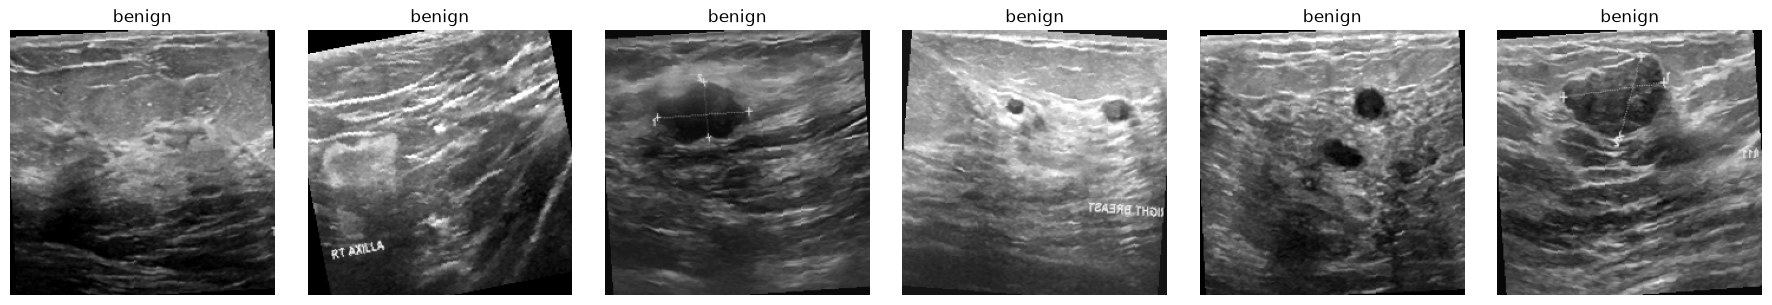

In [7]:
def denormalize(img_tensor):
    """把归一化后的 tensor 还原成可以直接显示的图片（0~1 之间）。"""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()


sample_imgs, sample_labels = next(iter(train_loader))
n_show = min(6, len(sample_imgs))

fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1:
    axes = [axes]
for i in range(n_show):
    axes[i].imshow(denormalize(sample_imgs[i]))
    axes[i].set_title(CLASS_NAMES[sample_labels[i].item()])
    axes[i].axis("off")
plt.tight_layout()
plt.show()


## 6. 构建模型：ResNet50 + ImageNet 预训练权重

- 加载在 ImageNet 上预训练好的 ResNet50，利用它已经学到的通用图像特征（边缘、纹理、形状等），而不是从零开始训练。
- 把原本 1000 类（ImageNet 类别数）的最后一层全连接层，换成输出 2 类（benign / malignant）的全连接层。


In [8]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

num_features = model.fc.in_features       # ResNet50 最后一层全连接层的输入维度
model.fc = nn.Sequential(
    nn.Dropout(p=DROPOUT_P),               # 训练时随机丢弃部分神经元，缓解过拟合
    nn.Linear(num_features, len(CLASS_NAMES)),  # 换成二分类输出
)

model = model.to(device)
print(model.fc)


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=2048, out_features=2, bias=True)
)


## 7. 定义损失函数与优化器

- **损失函数**：交叉熵损失（CrossEntropyLoss），标准的多分类/二分类损失函数。
- **优化器**：Adam，学习率用 CONFIG 里设置的 `LEARNING_RATE`。


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


## 8. 训练循环

每个 epoch 做两件事：
1. **训练阶段**：在训练集上做前向传播（forward）+ 反向传播（backward）+ 更新参数，记录平均 train loss。
2. **评估阶段**：在测试集上只做前向传播（不更新参数），记录平均 test loss，同时顺便算一下当前的测试集准确率。

用 `history` 字典把每个 epoch 的 train loss / test loss 都存下来，方便之后画 loss 曲线。


In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()  # 切换到训练模式（启用 dropout/batchnorm 的训练行为）
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # 清空上一步残留的梯度
        outputs = model(images)        # 前向传播
        loss = criterion(outputs, labels)
        loss.backward()                # 反向传播，计算梯度
        optimizer.step()               # 根据梯度更新参数

        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()  # 评估阶段不需要计算梯度，节省显存/计算
def evaluate(model, loader, criterion, device):
    model.eval()  # 切换到评估模式
    running_loss = 0.0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_preds, all_labels


In [11]:
history = {"train_loss": [], "test_loss": [], "test_acc": [], "test_f1": []}

best_f1 = -1.0
best_state = None
epochs_no_improve = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
    test_f1 = f1_score(test_labels, test_preds)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    history["test_f1"].append(test_f1)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | train_loss={train_loss:.4f} | "
          f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f} | test_f1={test_f1:.4f}")

    # 用 test F1 判断"是不是变好了"：这个数据集良恶性两类样本数不均衡（437 vs 210），
    # F1 比单看 accuracy 更能反映两类是否都分得好。连续 EARLY_STOPPING_PATIENCE 个 epoch
    # 没提升就提前停止，避免像 Job 44 那样一直训练到 train loss 趋近 0 但更过拟合。
    if test_f1 > best_f1:
        best_f1 = test_f1
        best_state = {k: v.clone().cpu() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"Test F1 连续 {EARLY_STOPPING_PATIENCE} 个 epoch 没有提升，"
                  f"提前停止训练（第 {epoch} 轮）。")
            break

# 加载 test F1 最高那一轮的权重，而不是最后一轮——最后一轮 train loss 最低不代表泛化最好
model.load_state_dict(best_state)
print(f"已加载 test F1 最高的权重（F1={best_f1:.4f}）")


Epoch 01/20 | train_loss=0.6206 | test_loss=0.5508 | test_acc=0.7000 | test_f1=0.8235


Epoch 02/20 | train_loss=0.4706 | test_loss=0.4554 | test_acc=0.8077 | test_f1=0.8718


Epoch 03/20 | train_loss=0.3291 | test_loss=0.3812 | test_acc=0.8308 | test_f1=0.8842


Epoch 04/20 | train_loss=0.2510 | test_loss=0.3075 | test_acc=0.8692 | test_f1=0.9110


Epoch 05/20 | train_loss=0.1959 | test_loss=0.3734 | test_acc=0.8462 | test_f1=0.8901


...

Epoch 17/20 | train_loss=0.0561 | test_loss=0.3569 | test_acc=0.9077 | test_f1=0.9341


Epoch 18/20 | train_loss=0.0560 | test_loss=0.3934 | test_acc=0.9154 | test_f1=0.9405


Epoch 19/20 | train_loss=0.0618 | test_loss=0.5422 | test_acc=0.9000 | test_f1=0.9305


Epoch 20/20 | train_loss=0.0973 | test_loss=0.3496 | test_acc=0.9385 | test_f1=0.9565


已加载 test F1 最高的权重（F1=0.9565）


## 9. 绘制 Loss 曲线

观察 train loss 和 test loss 随 epoch 的变化：
- 如果两条曲线都在下降，说明模型还在学习（可能欠拟合 underfitting，还没训够）。
- 如果 train loss 持续下降但 test loss 开始回升，说明模型开始**过拟合（overfitting）**——在训练集上学得很好，但泛化能力变差。
- 好的训练轮数（epoch 数），一般选在 test loss 最低、还没有明显回升的地方。


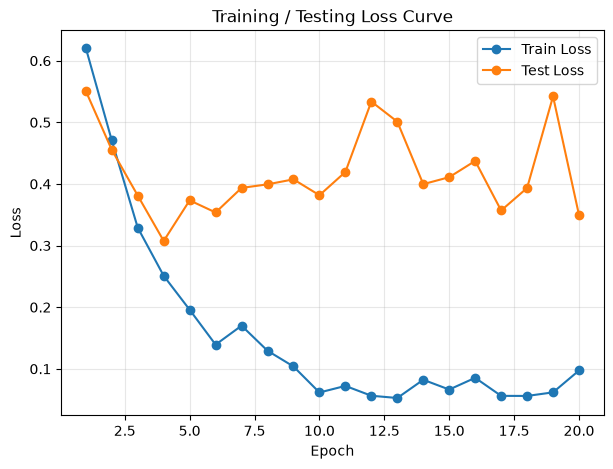

Loss 曲线已保存到: /mnt/cv_data/users/hahaxixi/projects/research_training/outputs/loss_curve.png


In [12]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
plt.plot(epochs_range, history["test_loss"], label="Test Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Testing Loss Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(LOSS_CURVE_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("Loss 曲线已保存到:", LOSS_CURVE_PATH)


### 9.1 过拟合分析（草稿，待自己改写精简）

从 loss 曲线看：train loss 从 epoch 1 的 0.6174 一路降到 epoch 20 的 0.0069，几乎完美拟合了训练集；
但 test loss 只在 epoch 4 附近降到最低点（0.2901），之后不再下降，反而在 0.29~0.53 之间反复震荡，
epoch 15 甚至回升到 0.5318。这说明 epoch 4 之后模型已经进入**过拟合**：模型在"死记"训练集里的
细节，而不是学习能泛化到新图片的特征。可能原因是训练集只有 517 张图，对 ResNet50 这种大容量模型
偏小，加上数据增强只有水平翻转、又没有 dropout/weight decay 等正则化手段，导致模型很容易记住训练
样本。常见对策：early stopping（在 test loss 最低的 epoch 4 附近停止/保存 checkpoint）、加强数据
增强（随机裁剪、旋转、颜色扰动）、在全连接层前加 dropout、给优化器加 weight decay。


## 10. 在测试集上计算分类指标

用标准的分类评估指标：
- **Accuracy（准确率）**：预测对的比例。
- **Precision（精确率）**：预测为“恶性”的样本里，真正是恶性的比例。
- **Recall（召回率）**：真正是“恶性”的样本里，被正确预测出来的比例（在医学场景里通常很重要——不想漏掉恶性病例）。
- **F1 score**：precision 和 recall 的调和平均，综合考虑两者。
- **混淆矩阵（confusion matrix）**：更直观地看到哪类样本容易被搞混。


In [13]:
final_test_loss, final_test_acc, final_preds, final_labels = evaluate(model, test_loader, criterion, device)

precision = precision_score(final_labels, final_preds)
recall = recall_score(final_labels, final_preds)
f1 = f1_score(final_labels, final_preds)
cm = confusion_matrix(final_labels, final_preds)

print(f"Test Accuracy : {final_test_acc:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 score      : {f1:.4f}")
print("Confusion matrix (行=真实标签, 列=预测标签):")
print(cm)

# ===== 和 Job 44 的基线对比（旧版本：无 weight decay / dropout / 弱数据增强 / 无 early stopping，
# 20 epoch 跑满，train loss 降到 0.007 但明显过拟合）=====
baseline = {"accuracy": 0.9077, "precision": 0.9247, "recall": 0.9451, "f1": 0.9348}
current = {"accuracy": final_test_acc, "precision": precision, "recall": recall, "f1": f1}
print("\n指标对比（baseline = Job 44）：")
for name in ["accuracy", "precision", "recall", "f1"]:
    delta = current[name] - baseline[name]
    print(f"  {name:10s}: {baseline[name]:.4f} -> {current[name]:.4f}  ({delta:+.4f})")


Test Accuracy : 0.9385
Precision     : 0.9462
Recall        : 0.9670
F1 score      : 0.9565
Confusion matrix (行=真实标签, 列=预测标签):
[[34  5]
 [ 3 88]]

指标对比（baseline = Job 44）：
  accuracy  : 0.9077 -> 0.9385  (+0.0308)
  precision : 0.9247 -> 0.9462  (+0.0215)
  recall    : 0.9451 -> 0.9670  (+0.0219)
  f1        : 0.9348 -> 0.9565  (+0.0217)


## 11. 可视化预测结果

遍历测试集里的每一张图片，显示：**图片本身 + 真实标签 + 预测标签**。
预测错误的图片会用红色标题标出来，方便一眼看出模型容易在哪些图上犯错。

⚠️ 如果测试集很大，这一步会输出很多张图；可以把下面的 `MAX_IMAGES_TO_SHOW` 调小一点先看看效果。


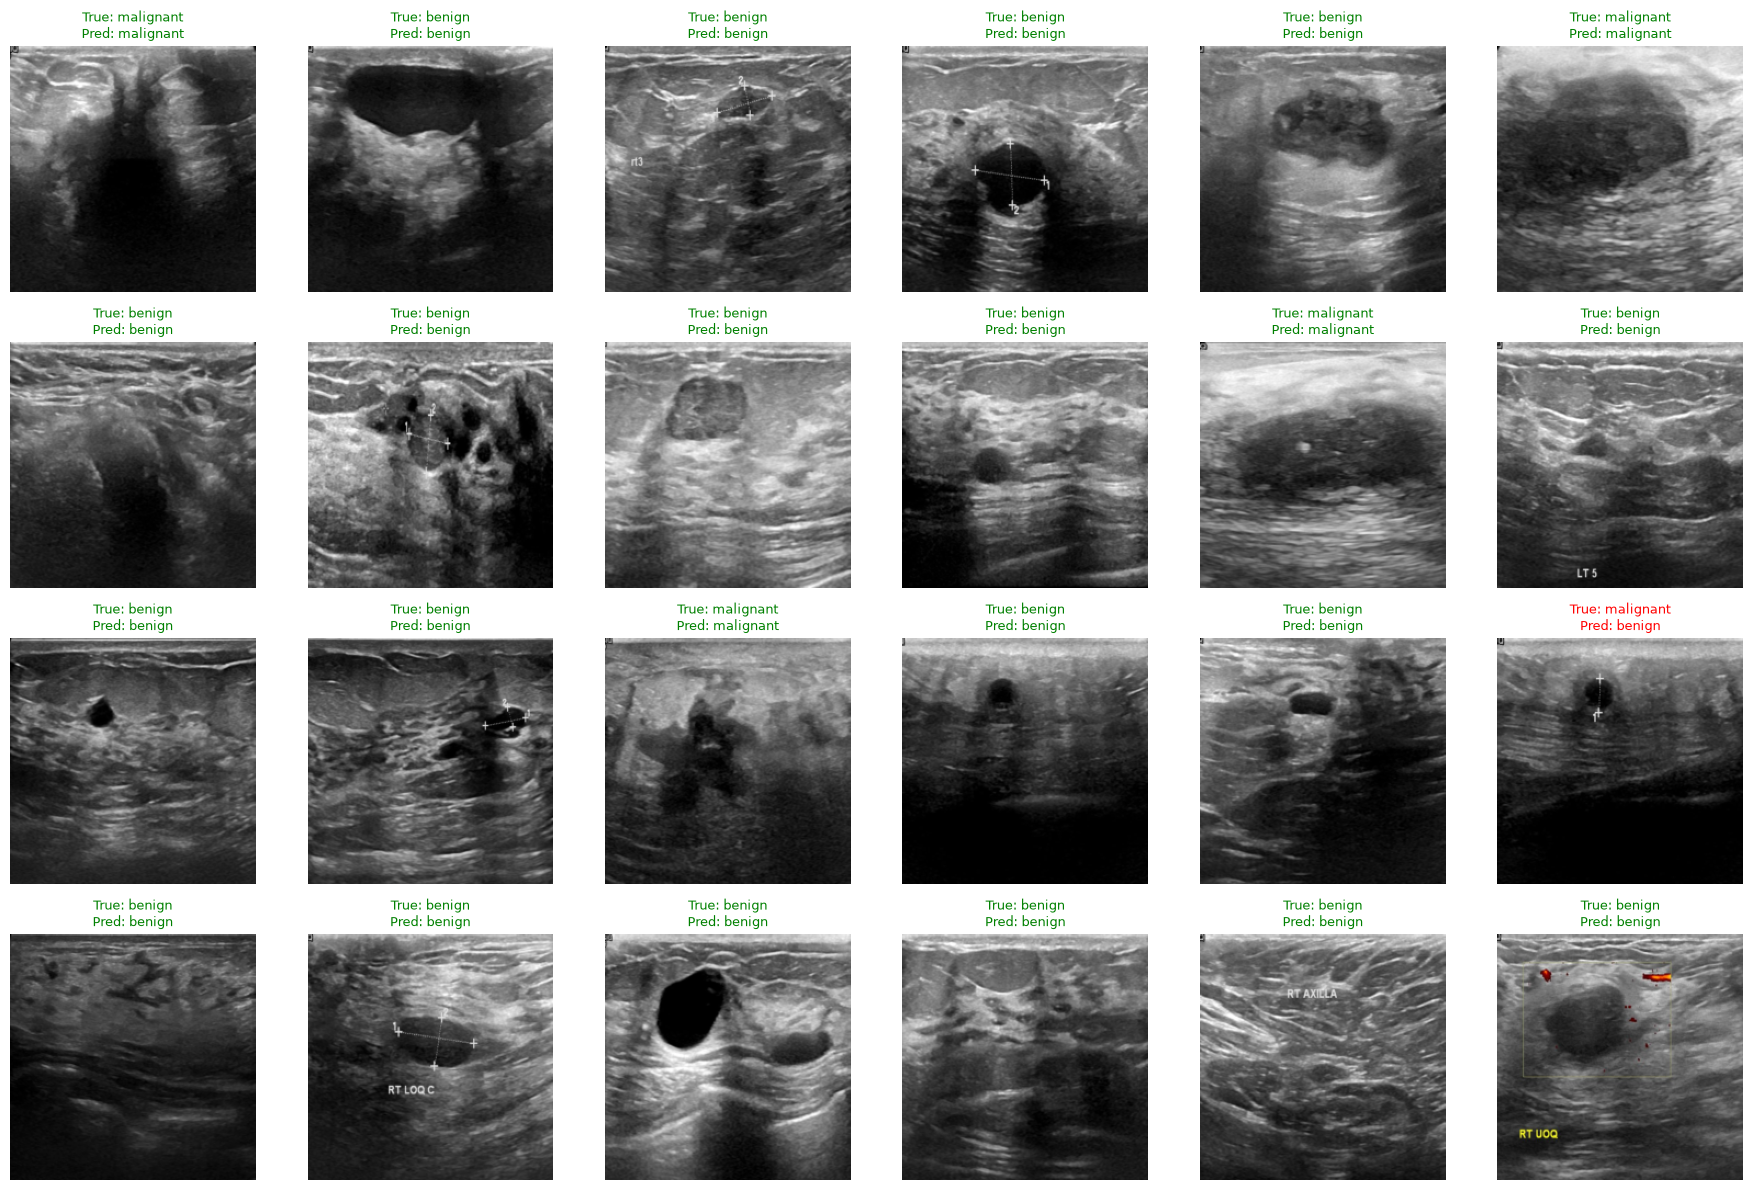

In [14]:
MAX_IMAGES_TO_SHOW = 24  # 想看全部测试图片就设成 len(test_dataset)

model.eval()
n_show = min(MAX_IMAGES_TO_SHOW, len(test_dataset))
n_cols = 6
n_rows = (n_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes = np.array(axes).reshape(-1)

with torch.no_grad():
    for i in range(n_show):
        image, true_label = test_dataset[i]
        output = model(image.unsqueeze(0).to(device))
        pred_label = output.argmax(dim=1).item()

        ax = axes[i]
        ax.imshow(denormalize(image))
        # 注意：标题用英文 True/Pred，因为服务器上 matplotlib 默认字体不支持中文，
        # 中文会显示成方框乱码
        title = f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]}"
        ax.set_title(title, color=("green" if pred_label == true_label else "red"), fontsize=9)
        ax.axis("off")

for j in range(n_show, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


## 12. 保存模型

把训练好的模型权重保存下来，之后可以直接加载，不用重新训练。


In [15]:
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print("模型已保存到:", MODEL_SAVE_PATH)


模型已保存到: /mnt/cv_data/users/hahaxixi/projects/research_training/outputs/resnet50_busi_final.pt
